<a href="https://colab.research.google.com/github/joshuajhchoi/ai2learn/blob/master/regularization_regression_en.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regularized Regression (Ridge vs Lasso) Tutorial

In this notebook, we will compare Ridge and Lasso regression, which are regularization techniques used to prevent overfitting in linear regression models. Both methods aim to improve generalization performance by limiting model complexity.

## 1. Import Required Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import make_regression

# Visualization settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Set random seed
np.random.seed(42)

## 2. Generate Data

First, we'll create an artificial dataset for regression analysis. This dataset is designed to include features with multicollinearity to demonstrate the effects of regularization.

In [ ]:
# Generate artificial dataset
X, y = make_regression(n_samples=200, n_features=20, n_informative=10,
                       noise=20, random_state=42)

# Add multicollinearity by making some features linear combinations of others
X[:, 5] = X[:, 1] * 0.8 + X[:, 2] * 0.2 + np.random.normal(0, 0.1, X.shape[0])
X[:, 15] = X[:, 10] * 0.7 + X[:, 8] * 0.3 + np.random.normal(0, 0.1, X.shape[0])

# Check data dimensions
print(f"Data shape: {X.shape}, Target shape: {y.shape}")

# Convert to DataFrame
df = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(X.shape[1])])
df['target'] = y

# Preview data
df.head()

Data shape: (200, 20), Target shape: (200,)


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,target
0,0.198085,-0.144360,0.059218,-0.272724,-0.335785,-0.053973,0.013929,-1.503143,-0.245743,-0.054295,...,1.126565,-1.106526,-0.259591,-2.696887,0.449400,2.573360,1.848956,1.669022,-0.268889,-249.654438
1,-0.968046,-0.310308,-0.397558,1.171718,-0.399899,-0.341584,1.237654,0.182501,-0.670115,0.487560,...,-0.528297,-1.422975,-0.044893,-1.176173,0.191680,-0.970124,-0.202524,0.269295,1.036088,-36.004789
2,-0.388177,0.170416,-0.337086,-1.975467,0.056650,0.133685,-0.613403,0.486502,0.064474,-0.144088,...,1.218762,1.490726,-0.070499,-0.939335,0.547598,0.148667,1.530751,0.529693,-0.213443,-80.374940
3,0.513908,0.179582,1.938929,1.187679,0.403730,0.683754,-1.000331,0.324359,-1.179040,0.201160,...,-0.474904,-1.345980,-0.903702,-0.464617,-0.429565,0.126380,0.586694,-0.024196,0.871297,-112.745566
4,-0.552223,0.632932,-0.570746,0.492451,-0.049464,0.368781,-0.832356,0.382410,0.166452,2.455300,...,-0.555477,1.189017,-1.122722,0.289169,-0.459529,1.420504,-0.623141,0.674819,-0.637387,30.043768


## 3. Data Exploration and Preprocessing

In [ ]:
# Check basic statistics
df.describe()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,target
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,...,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,0.095857,0.078436,0.060024,-0.023906,0.118107,0.070677,0.002095,-0.039981,-0.041669,0.049606,...,0.002344,-0.001875,-0.037622,-0.095751,0.083394,0.071443,-0.075203,0.070502,0.040172,-5.157718
std,0.961353,0.909686,1.079111,1.014562,0.947236,0.764654,0.981475,0.976775,1.009479,0.961080,...,1.100523,0.995014,1.061102,1.023642,0.775549,1.060126,0.910546,1.042968,0.990543,157.937438
min,-2.604214,-2.872262,-2.591042,-2.532246,-2.499406,-2.620333,-2.635748,-2.390304,-3.019512,-2.991136,...,-2.940389,-2.198806,-3.241267,-2.696887,-1.799193,-2.929449,-2.703232,-2.896255,-2.906988,-471.596529
25%,-0.552580,-0.435979,-0.583048,-0.804024,-0.560505,-0.414814,-0.670177,-0.824742,-0.679842,-0.696975,...,-0.750615,-0.771787,-0.705359,-0.812197,-0.402404,-0.653336,-0.623746,-0.580119,-0.646181,-92.805519
50%,0.129911,0.089929,0.037928,0.043514,0.176456,0.105326,-0.019075,-0.045594,-0.058241,0.030920,...,-0.031868,0.024420,-0.028554,-0.064299,0.063128,-0.018862,-0.067140,0.016539,0.048915,-4.619684
75%,0.729682,0.638837,0.731732,0.668974,0.700248,0.579228,0.648027,0.698653,0.627523,0.689014,...,0.755647,0.710613,0.634013,0.557876,0.610102,0.829423,0.588410,0.745732,0.633819,105.566923
max,3.078881,2.720169,3.926238,3.109919,2.526932,2.367560,3.243093,2.270693,2.426716,2.455300,...,2.558199,2.601683,3.152057,2.949094,2.334990,2.644343,1.848956,2.985259,2.303639,373.915249


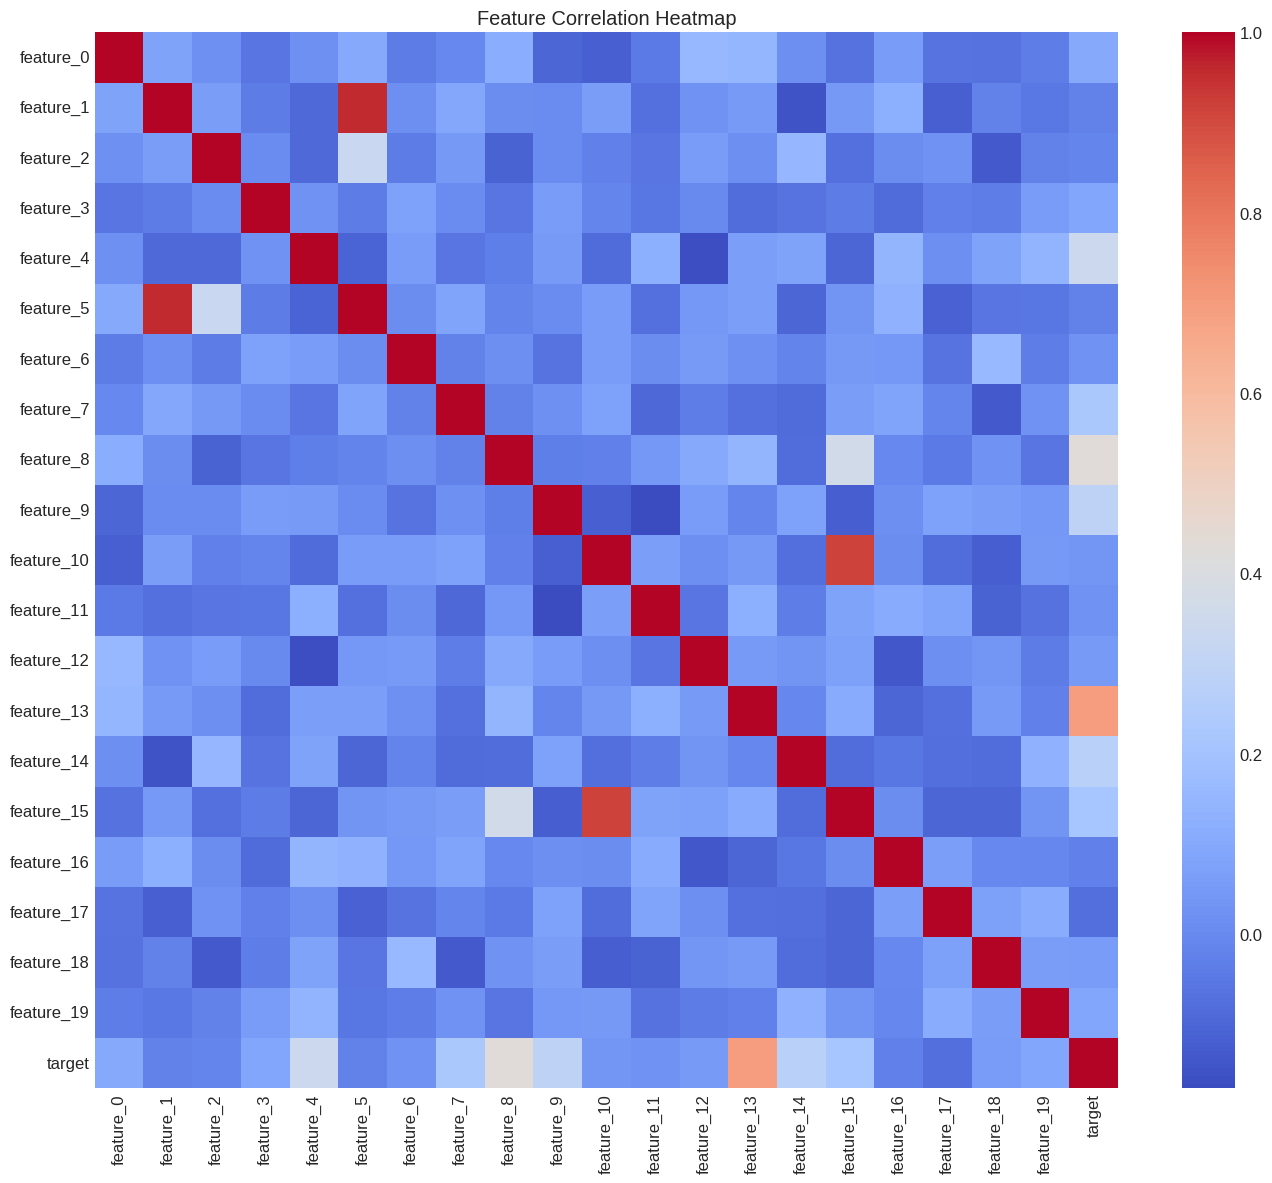

In [ ]:
# Check correlation between features
plt.figure(figsize=(14, 12))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

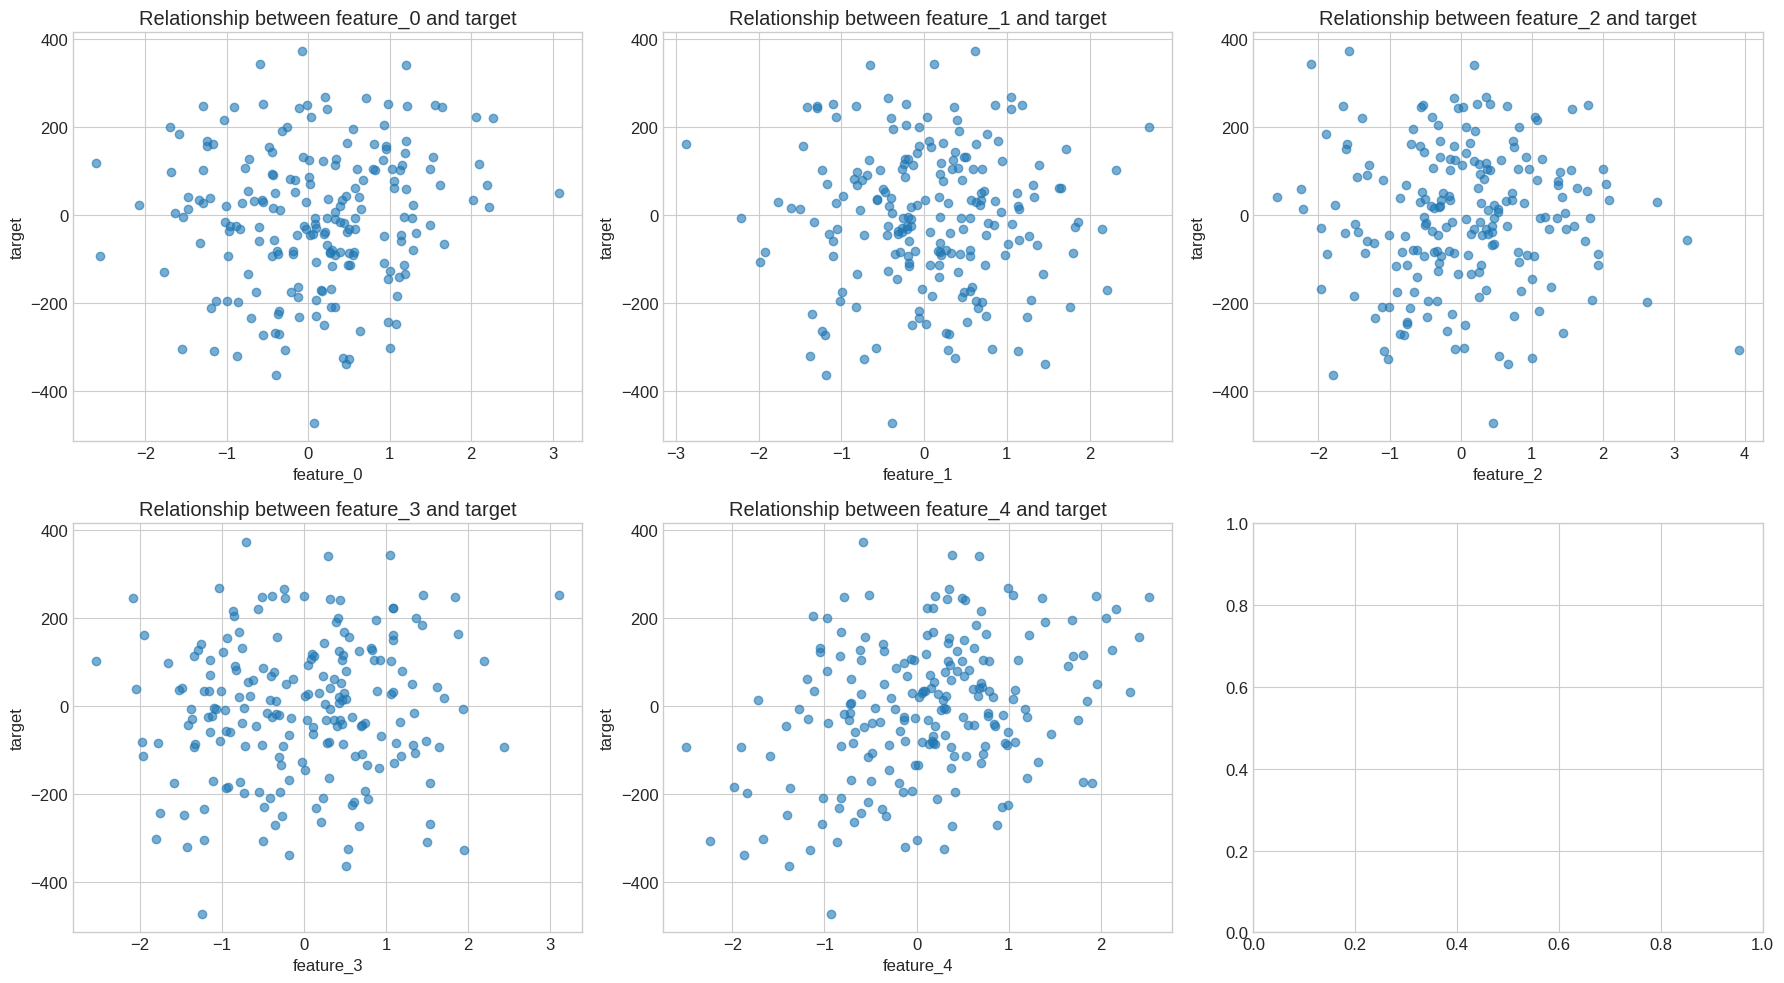

In [ ]:
# Visualize relationship between features and target (first 5 features only)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, ax in enumerate(axes[:5]):
    ax.scatter(df[f'feature_{i}'], df['target'], alpha=0.6)
    ax.set_xlabel(f'feature_{i}')
    ax.set_ylabel('target')
    ax.set_title(f'Relationship between feature_{i} and target')

plt.tight_layout()
plt.show()

In [ ]:
# Split data into training and test sets
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training data size: {X_train.shape}, Test data size: {X_test.shape}")

Training data size: (160, 20), Test data size: (40, 20)


In [ ]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Check scaling results
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
print("Statistics after scaling:")
X_train_scaled_df.describe().loc[['mean', 'std']].round(2)

Statistics after scaling:


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19
mean,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## 4. Train and Evaluate Basic Linear Regression Model

In [ ]:
# Train basic linear regression model
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Predict and evaluate
y_train_pred_lr = lr.predict(X_train_scaled)
y_test_pred_lr = lr.predict(X_test_scaled)

# Calculate evaluation metrics
train_mse_lr = mean_squared_error(y_train, y_train_pred_lr)
test_mse_lr = mean_squared_error(y_test, y_test_pred_lr)
train_r2_lr = r2_score(y_train, y_train_pred_lr)
test_r2_lr = r2_score(y_test, y_test_pred_lr)

print("Basic Linear Regression Model Performance:")
print(f"Training MSE: {train_mse_lr:.2f}, Test MSE: {test_mse_lr:.2f}")
print(f"Training R²: {train_r2_lr:.4f}, Test R²: {test_r2_lr:.4f}")

Basic Linear Regression Model Performance:
Training MSE: 426.15, Test MSE: 390.81
Training R²: 0.9830, Test R²: 0.9835


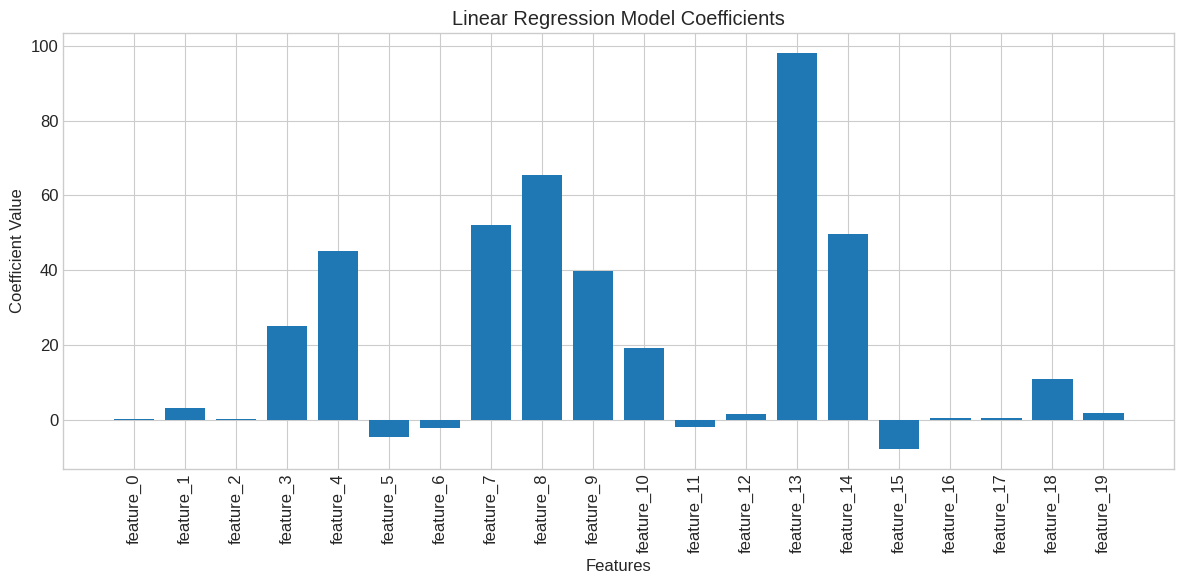

In [ ]:
# Visualize linear regression coefficients
plt.figure(figsize=(12, 6))
plt.bar(X.columns, lr.coef_)
plt.title('Linear Regression Model Coefficients')
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 5. Train and Evaluate Ridge Regression Model

Ridge regression uses L2 regularization, which minimizes the sum of squared coefficients. This shrinks all coefficients but doesn't reduce any to exactly zero.

In [ ]:
# Train Ridge regression models with various alpha values
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
ridge_models = {}
ridge_train_mse = []
ridge_test_mse = []
ridge_train_r2 = []
ridge_test_r2 = []
ridge_coefs = []

for alpha in alphas:
    # Train model
    ridge = Ridge(alpha=alpha, random_state=42)
    ridge.fit(X_train_scaled, y_train)
    ridge_models[alpha] = ridge

    # Predict and evaluate
    y_train_pred = ridge.predict(X_train_scaled)
    y_test_pred = ridge.predict(X_test_scaled)

    # Store evaluation metrics
    ridge_train_mse.append(mean_squared_error(y_train, y_train_pred))
    ridge_test_mse.append(mean_squared_error(y_test, y_test_pred))
    ridge_train_r2.append(r2_score(y_train, y_train_pred))
    ridge_test_r2.append(r2_score(y_test, y_test_pred))
    ridge_coefs.append(ridge.coef_)

    print(f"Ridge Regression (alpha={alpha})")
    print(f"Training MSE: {ridge_train_mse[-1]:.2f}, Test MSE: {ridge_test_mse[-1]:.2f}")
    print(f"Training R²: {ridge_train_r2[-1]:.4f}, Test R²: {ridge_test_r2[-1]:.4f}")
    print("-" * 50)

Ridge Regression (alpha=0.01)
Training MSE: 426.15, Test MSE: 390.86
Training R²: 0.9830, Test R²: 0.9835
--------------------------------------------------
Ridge Regression (alpha=0.1)
Training MSE: 426.23, Test MSE: 391.29
Training R²: 0.9830, Test R²: 0.9835
--------------------------------------------------
Ridge Regression (alpha=1.0)
Training MSE: 429.16, Test MSE: 392.25
Training R²: 0.9829, Test R²: 0.9835
--------------------------------------------------
Ridge Regression (alpha=10.0)
Training MSE: 509.95, Test MSE: 375.51
Training R²: 0.9797, Test R²: 0.9842
--------------------------------------------------
Ridge Regression (alpha=100.0)
Training MSE: 3681.41, Test MSE: 3118.04
Training R²: 0.8532, Test R²: 0.8687
--------------------------------------------------


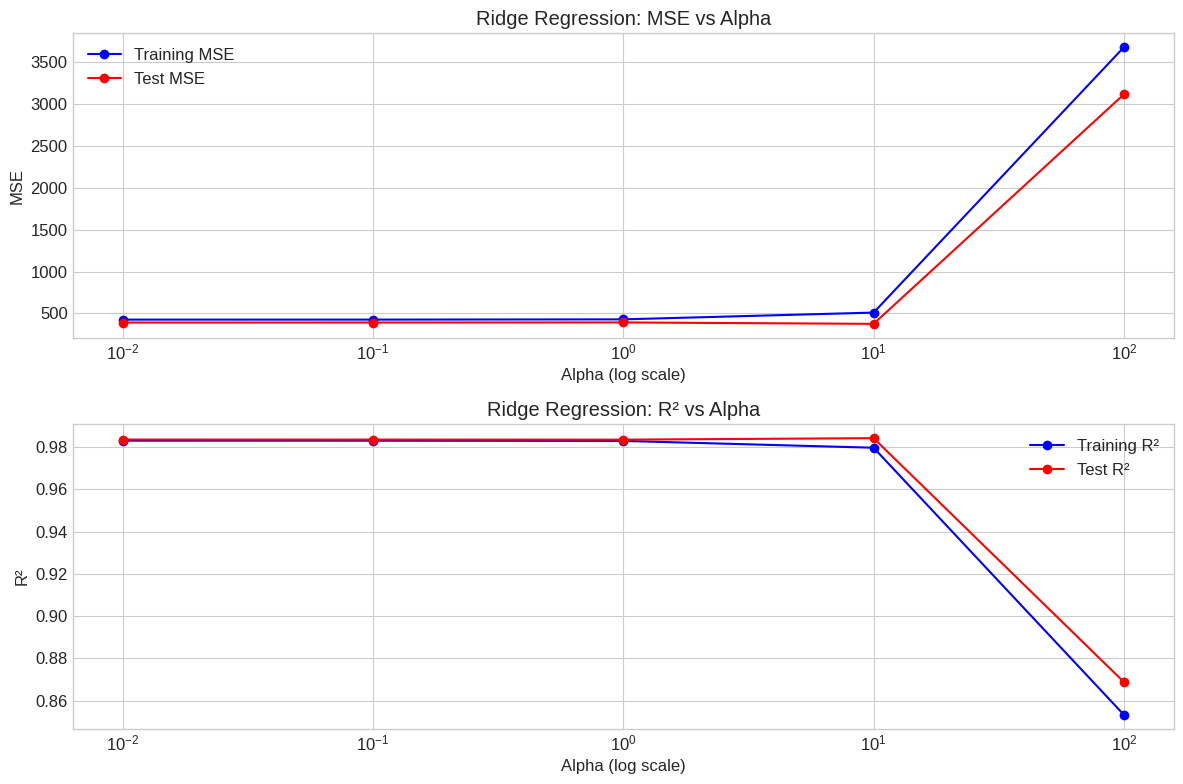

In [ ]:
# Visualize performance changes with different alpha values for Ridge regression
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.semilogx(alphas, ridge_train_mse, 'b-o', label='Training MSE')
plt.semilogx(alphas, ridge_test_mse, 'r-o', label='Test MSE')
plt.xlabel('Alpha (log scale)')
plt.ylabel('MSE')
plt.title('Ridge Regression: MSE vs Alpha')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.semilogx(alphas, ridge_train_r2, 'b-o', label='Training R²')
plt.semilogx(alphas, ridge_test_r2, 'r-o', label='Test R²')
plt.xlabel('Alpha (log scale)')
plt.ylabel('R²')
plt.title('Ridge Regression: R² vs Alpha')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

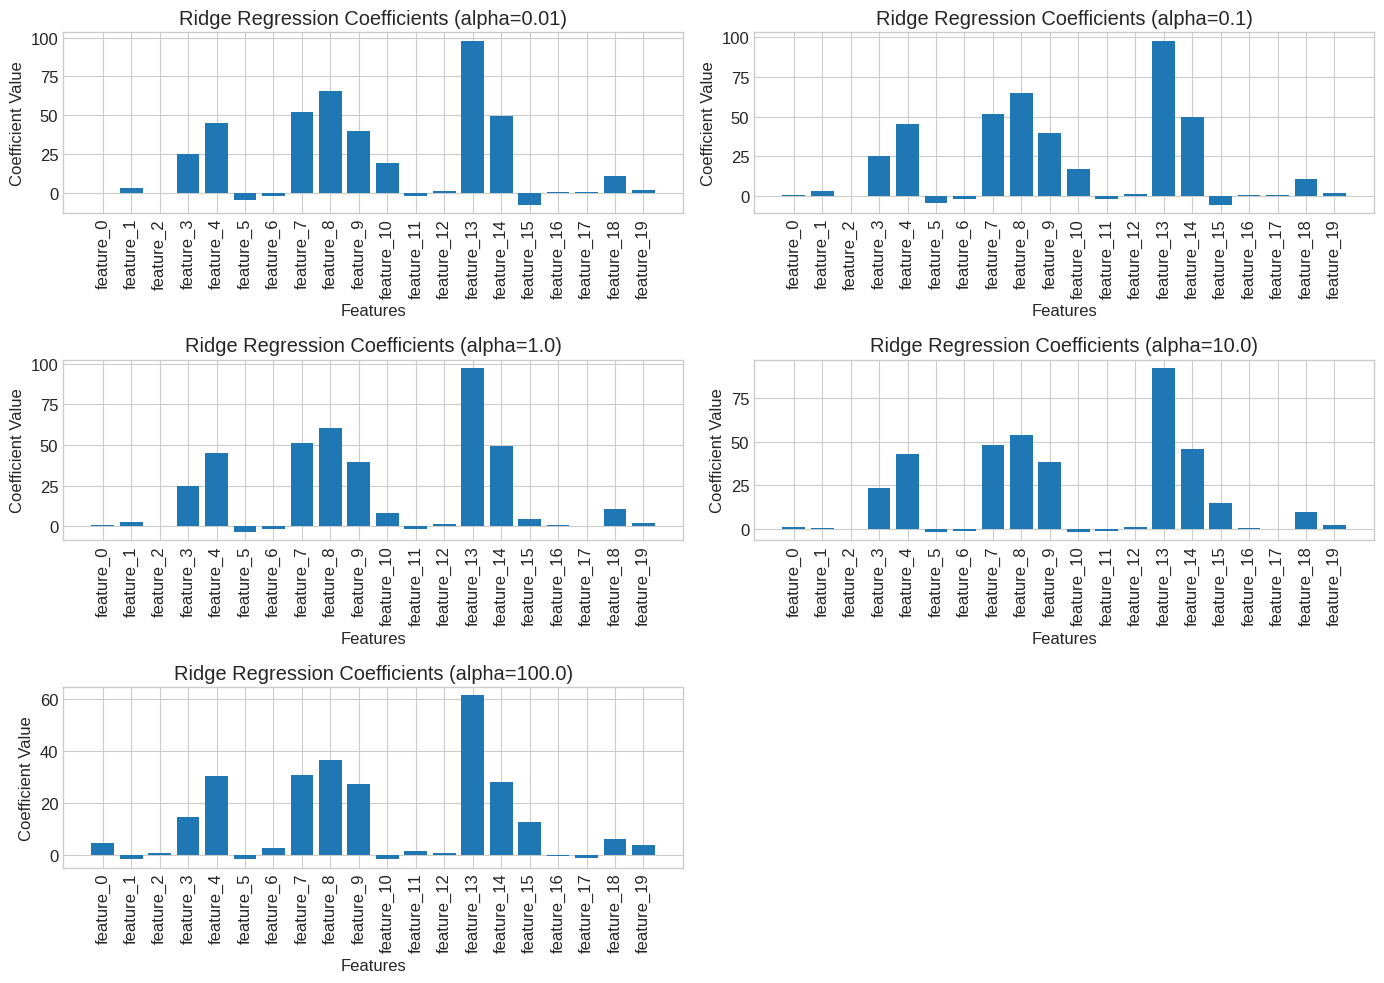

In [ ]:
# Visualize coefficient changes with different alpha values for Ridge regression
plt.figure(figsize=(14, 10))

for i, alpha in enumerate(alphas):
    plt.subplot(3, 2, i+1)
    plt.bar(X.columns, ridge_coefs[i])
    plt.title(f'Ridge Regression Coefficients (alpha={alpha})')
    plt.xlabel('Features')
    plt.ylabel('Coefficient Value')
    plt.xticks(rotation=90)
    plt.tight_layout()

plt.tight_layout()
plt.show()

## 6. Train and Evaluate Lasso Regression Model

Lasso regression uses L1 regularization, which minimizes the sum of absolute values of coefficients. This tends to reduce some coefficients to exactly zero, providing a feature selection effect.

In [ ]:
# Train Lasso regression models with various alpha values
alphas = [0.0001, 0.001, 0.01, 0.1, 1.0]
lasso_models = {}
lasso_train_mse = []
lasso_test_mse = []
lasso_train_r2 = []
lasso_test_r2 = []
lasso_coefs = []
lasso_n_nonzero = []

for alpha in alphas:
    # Train model
    lasso = Lasso(alpha=alpha, max_iter=10000, random_state=42)
    lasso.fit(X_train_scaled, y_train)
    lasso_models[alpha] = lasso

    # Predict and evaluate
    y_train_pred = lasso.predict(X_train_scaled)
    y_test_pred = lasso.predict(X_test_scaled)

    # Store evaluation metrics
    lasso_train_mse.append(mean_squared_error(y_train, y_train_pred))
    lasso_test_mse.append(mean_squared_error(y_test, y_test_pred))
    lasso_train_r2.append(r2_score(y_train, y_train_pred))
    lasso_test_r2.append(r2_score(y_test, y_test_pred))
    lasso_coefs.append(lasso.coef_)
    lasso_n_nonzero.append(np.sum(lasso.coef_ != 0))

    print(f"Lasso Regression (alpha={alpha})")
    print(f"Training MSE: {lasso_train_mse[-1]:.2f}, Test MSE: {lasso_test_mse[-1]:.2f}")
    print(f"Training R²: {lasso_train_r2[-1]:.4f}, Test R²: {lasso_test_r2[-1]:.4f}")
    print(f"Number of non-zero coefficients: {lasso_n_nonzero[-1]} / {X.shape[1]}")
    print("-" * 50)

Lasso Regression (alpha=0.0001)
Training MSE: 426.15, Test MSE: 390.84
Training R²: 0.9830, Test R²: 0.9835
Number of non-zero coefficients: 20 / 20
--------------------------------------------------
Lasso Regression (alpha=0.001)
Training MSE: 426.15, Test MSE: 391.17
Training R²: 0.9830, Test R²: 0.9835
Number of non-zero coefficients: 20 / 20
--------------------------------------------------
Lasso Regression (alpha=0.01)
Training MSE: 426.21, Test MSE: 393.63
Training R²: 0.9830, Test R²: 0.9834
Number of non-zero coefficients: 20 / 20
--------------------------------------------------
Lasso Regression (alpha=0.1)
Training MSE: 427.43, Test MSE: 399.63
Training R²: 0.9830, Test R²: 0.9832
Number of non-zero coefficients: 18 / 20
--------------------------------------------------
Lasso Regression (alpha=1.0)
Training MSE: 446.97, Test MSE: 399.42
Training R²: 0.9822, Test R²: 0.9832
Number of non-zero coefficients: 13 / 20
--------------------------------------------------


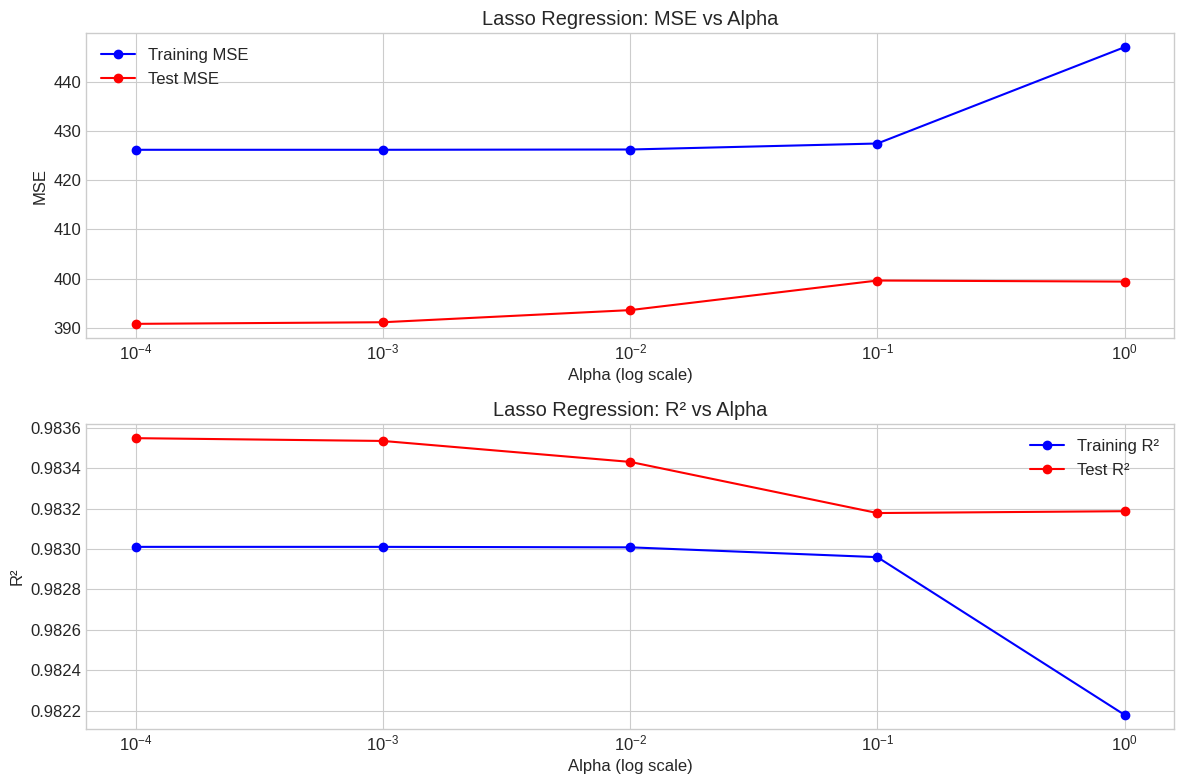

In [ ]:
# Visualize performance changes with different alpha values for Lasso regression
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.semilogx(alphas, lasso_train_mse, 'b-o', label='Training MSE')
plt.semilogx(alphas, lasso_test_mse, 'r-o', label='Test MSE')
plt.xlabel('Alpha (log scale)')
plt.ylabel('MSE')
plt.title('Lasso Regression: MSE vs Alpha')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.semilogx(alphas, lasso_train_r2, 'b-o', label='Training R²')
plt.semilogx(alphas, lasso_test_r2, 'r-o', label='Test R²')
plt.xlabel('Alpha (log scale)')
plt.ylabel('R²')
plt.title('Lasso Regression: R² vs Alpha')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

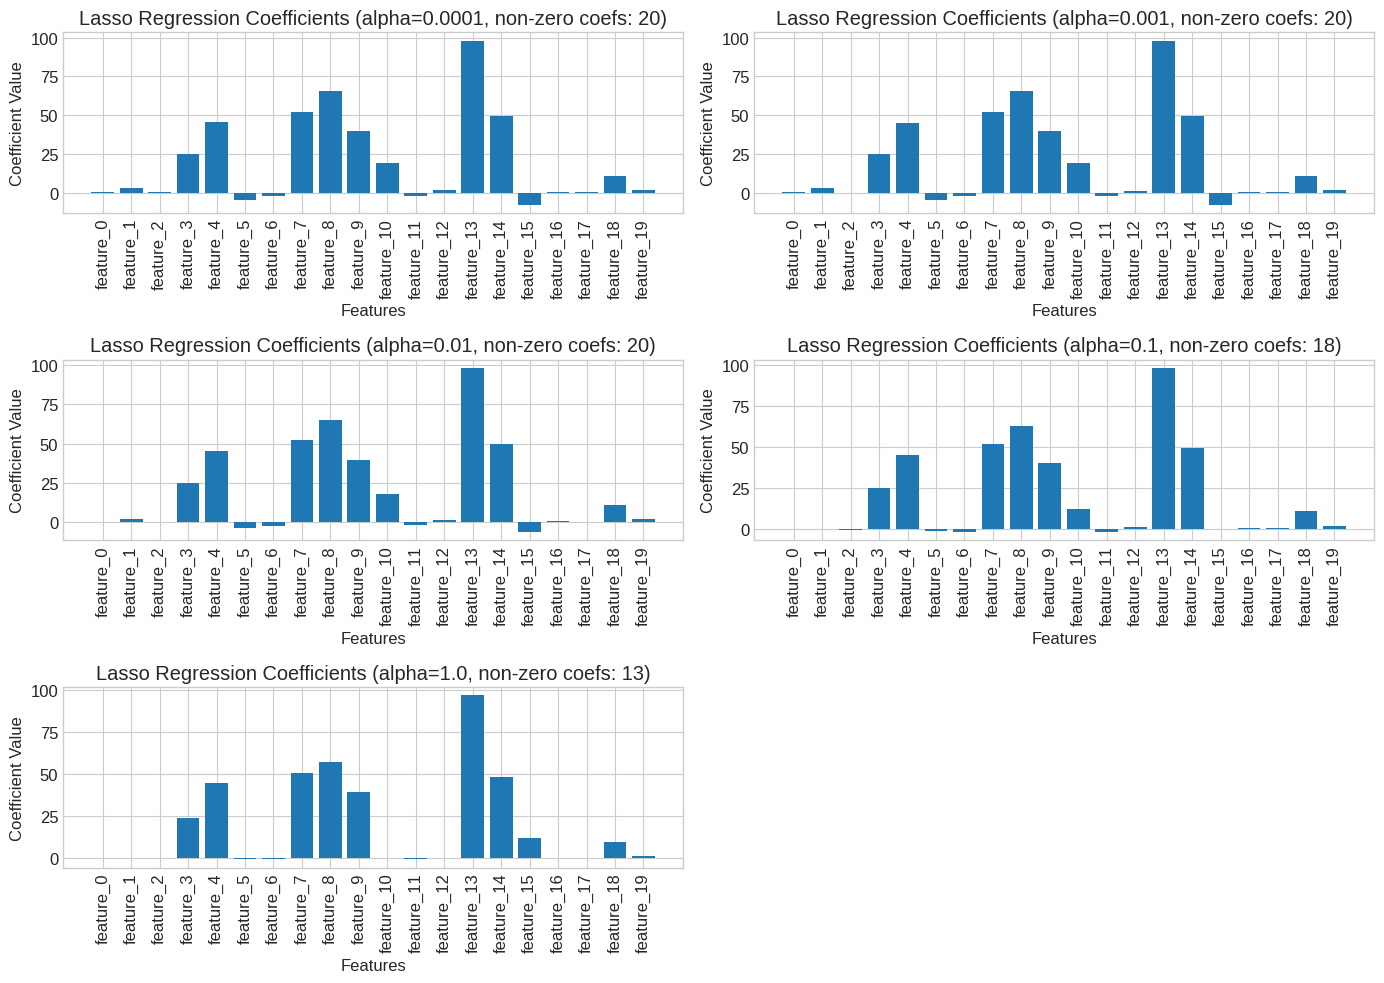

In [ ]:
# Visualize coefficient changes with different alpha values for Lasso regression
plt.figure(figsize=(14, 10))

for i, alpha in enumerate(alphas):
    plt.subplot(3, 2, i+1)
    plt.bar(X.columns, lasso_coefs[i])
    plt.title(f'Lasso Regression Coefficients (alpha={alpha}, non-zero coefs: {lasso_n_nonzero[i]})')
    plt.xlabel('Features')
    plt.ylabel('Coefficient Value')
    plt.xticks(rotation=90)
    plt.tight_layout()

plt.tight_layout()
plt.show()

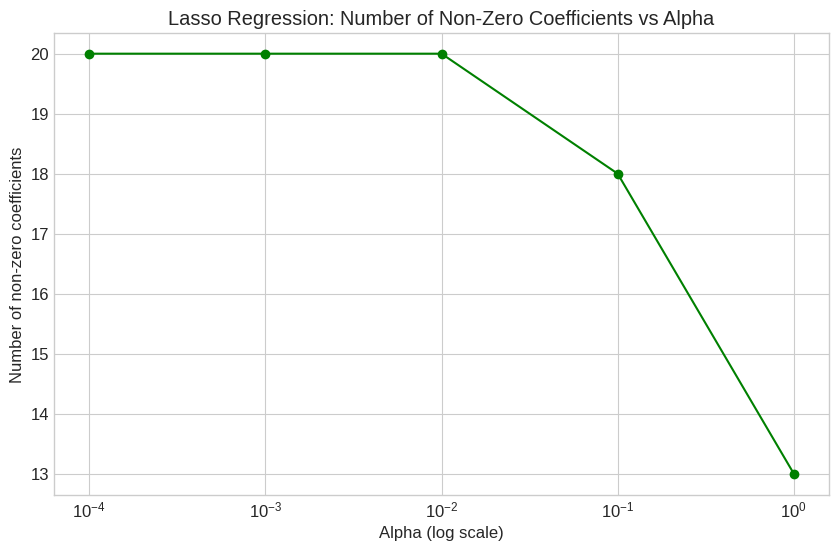

In [ ]:
# Visualize number of non-zero coefficients
plt.figure(figsize=(10, 6))
plt.semilogx(alphas, lasso_n_nonzero, 'g-o')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Number of non-zero coefficients')
plt.title('Lasso Regression: Number of Non-Zero Coefficients vs Alpha')
plt.grid(True)
plt.show()

## 7. Compare Ridge and Lasso Regression

In [ ]:
# Select the best Ridge and Lasso models
best_ridge_idx = np.argmin(ridge_test_mse)
best_lasso_idx = np.argmin(lasso_test_mse)

best_ridge_alpha = alphas[best_ridge_idx]
best_lasso_alpha = alphas[best_lasso_idx]

print(f"Best Ridge Model (alpha={best_ridge_alpha})")
print(f"Test MSE: {ridge_test_mse[best_ridge_idx]:.2f}, Test R²: {ridge_test_r2[best_ridge_idx]:.4f}")
print("\n")
print(f"Best Lasso Model (alpha={best_lasso_alpha})")
print(f"Test MSE: {lasso_test_mse[best_lasso_idx]:.2f}, Test R²: {lasso_test_r2[best_lasso_idx]:.4f}")
print(f"Number of non-zero coefficients: {lasso_n_nonzero[best_lasso_idx]} / {X.shape[1]}")

Best Ridge Model (alpha=0.1)
Test MSE: 375.51, Test R²: 0.9842


Best Lasso Model (alpha=0.0001)
Test MSE: 390.84, Test R²: 0.9835
Number of non-zero coefficients: 20 / 20


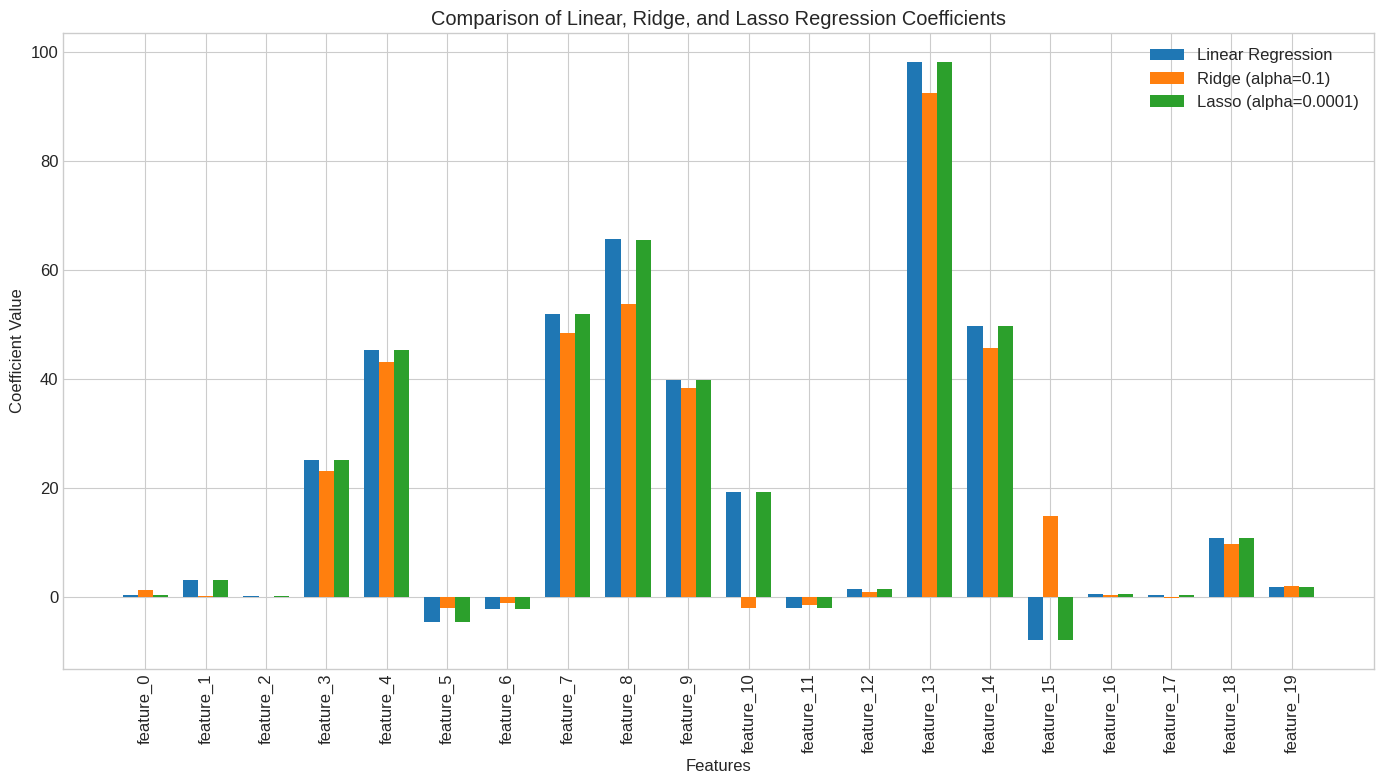

In [ ]:
# Compare coefficients of the three models
plt.figure(figsize=(14, 8))

width = 0.25
x = np.arange(len(X.columns))

plt.bar(x - width, lr.coef_, width, label='Linear Regression')
plt.bar(x, ridge_coefs[best_ridge_idx], width, label=f'Ridge (alpha={best_ridge_alpha})')
plt.bar(x + width, lasso_coefs[best_lasso_idx], width, label=f'Lasso (alpha={best_lasso_alpha})')

plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.title('Comparison of Linear, Ridge, and Lasso Regression Coefficients')
plt.xticks(x, X.columns, rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

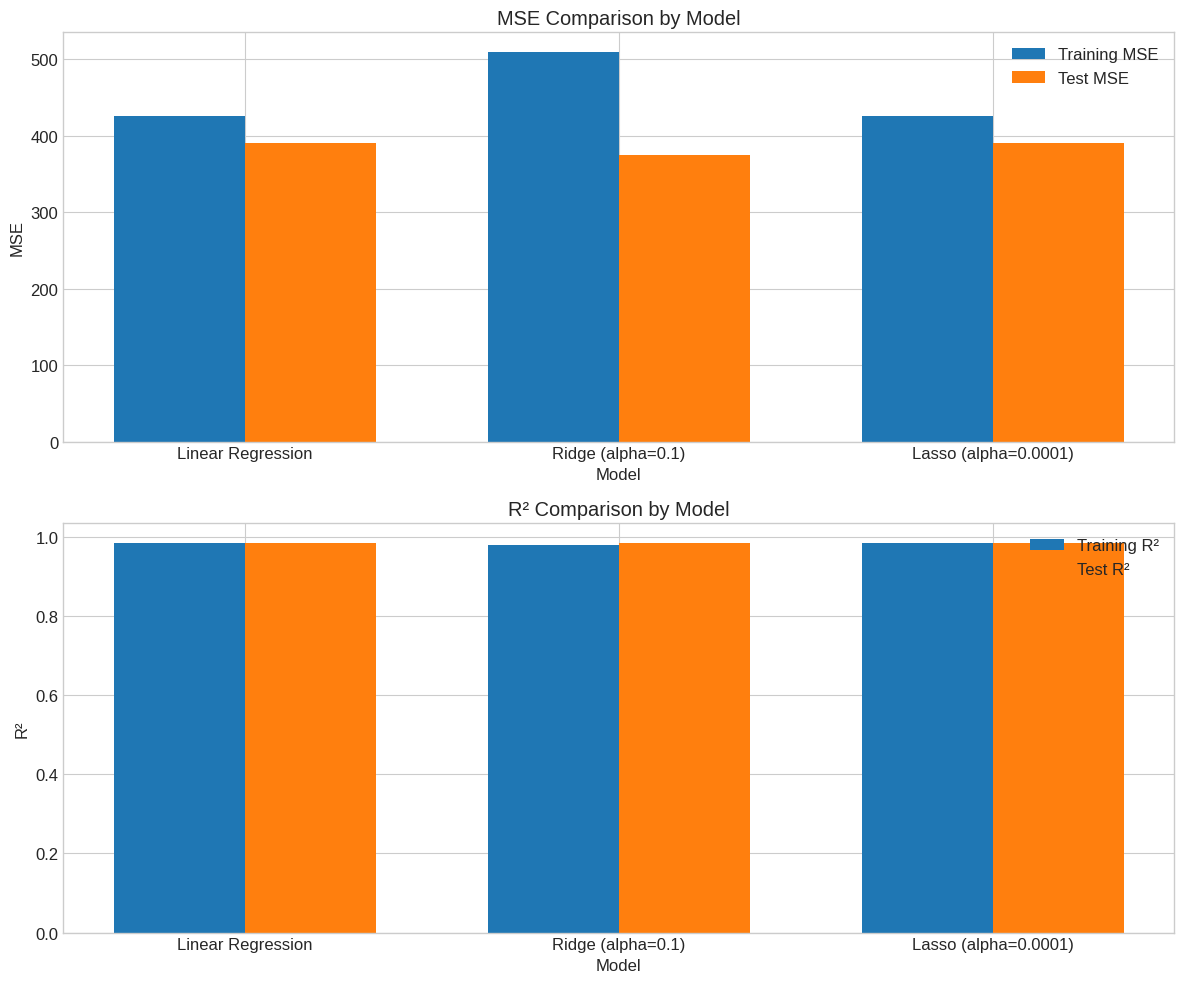

In [ ]:
# Compare performance of the three models
models = ['Linear Regression', f'Ridge (alpha={best_ridge_alpha})', f'Lasso (alpha={best_lasso_alpha})']
train_mse = [train_mse_lr, ridge_train_mse[best_ridge_idx], lasso_train_mse[best_lasso_idx]]
test_mse = [test_mse_lr, ridge_test_mse[best_ridge_idx], lasso_test_mse[best_lasso_idx]]
train_r2 = [train_r2_lr, ridge_train_r2[best_ridge_idx], lasso_train_r2[best_lasso_idx]]
test_r2 = [test_r2_lr, ridge_test_r2[best_ridge_idx], lasso_test_r2[best_lasso_idx]]

# Compare MSE
plt.figure(figsize=(12, 10))

plt.subplot(2, 1, 1)
x = np.arange(len(models))
width = 0.35
plt.bar(x - width/2, train_mse, width, label='Training MSE')
plt.bar(x + width/2, test_mse, width, label='Test MSE')
plt.xlabel('Model')
plt.ylabel('MSE')
plt.title('MSE Comparison by Model')
plt.xticks(x, models)
plt.legend()

# Compare R²
plt.subplot(2, 1, 2)
plt.bar(x - width/2, train_r2, width, label='Training R²')
plt.bar(x + width/2, test_r2, width, label='Test R²')
plt.xlabel('Model')
plt.ylabel('R²')
plt.title('R² Comparison by Model')
plt.xticks(x, models)
plt.legend()

plt.tight_layout()
plt.show()

## 8. Conclusion

In this tutorial, we compared Ridge and Lasso regression, which apply regularization to linear regression models. The key findings are:

1. **Basic Linear Regression**: Without regularization, there's a risk of overfitting, and coefficients can be unstable when multicollinearity is present.

2. **Ridge Regression**: Uses L2 regularization to shrink all coefficients but doesn't reduce any to exactly zero. It's effective when dealing with multicollinearity.

3. **Lasso Regression**: Uses L1 regularization to reduce some coefficients to exactly zero, providing a feature selection effect. It's useful when you want to retain only the most important features.

The alpha parameter, which controls the regularization strength, significantly impacts model performance, so finding the optimal value through cross-validation is important. Generally, Ridge works better when all features are somewhat important, while Lasso is more effective when only a subset of features are important.